# Дискретно-событийная модель SIR: набор параметров

Проверим, как на эпидемию влияют вероятность заражения $\beta$,
частота контактов $c$ и скорость выздоровления $\gamma$.
Для каждого набора выполняется один дискретно-событийный прогон
и для сравнения решается детерминированная модель.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, Plots, DataFrames, CSV

script_name = "sir_des_params"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data"

## Набор параметров

Функция `dict_list` строит все комбинации: 3 значения $\beta$,
3 значения $c$ и 2 значения $\gamma$ --- всего 18 прогонов.

In [2]:
des_dict = Dict(
    :β => [0.03, 0.05, 0.07],
    :c => [5.0, 10.0, 15.0],
    :γ => [0.25, 0.5],
    :u0 => [[990, 10, 0]],
    :tmax => 40.0,
    :seed => 1234,
)

des_list = dict_list(des_dict)
length(des_list)

18

## Функция одного эксперимента

Функция возвращает число $R_0 = \beta c / \gamma$, пик числа больных,
время пика и число переболевших к концу моделирования,
а также те же показатели детерминированной модели.

In [3]:
function run_des(p)
    q = [p[:β], p[:c], p[:γ]]
    Random.seed!(p[:seed])
    m = MakeSIRModel(p[:u0], q)
    activate(m)
    sir_run(m, p[:tmax])
    des = sir_metrics(out(m))
    ode = sir_metrics(sir_ode_solution(p[:u0], q, p[:tmax]))
    return (
        β = p[:β],
        c = p[:c],
        γ = p[:γ],
        R0 = round(p[:β] * p[:c] / p[:γ], digits = 2),
        peak_I = des.peak_I,
        t_peak = round(des.t_peak, digits = 1),
        final_R = des.final_R,
        peak_I_ode = round(ode.peak_I, digits = 1),
        final_R_ode = round(ode.final_R, digits = 1),
    )
end

run_des (generic function with 1 method)

## Запуск экспериментов

In [4]:
df_params = DataFrame([run_des(p) for p in des_list])
sort!(df_params, [:γ, :β, :c])
CSV.write(datadir("sir_des_params.csv"), df_params)
println(df_params)

18×9 DataFrame
 Row │ β        c        γ        R0       peak_I  t_peak   final_R  peak_I_ode  final_R_ode 
     │ Float64  Float64  Float64  Float64  Int64   Float64  Int64    Float64     Float64     
─────┼───────────────────────────────────────────────────────────────────────────────────────
   1 │    0.03      5.0     0.25      0.6      11      0.2       32        10.0         24.0
   2 │    0.03     10.0     0.25      1.2      24     37.9      116        23.1        187.8
   3 │    0.03     15.0     0.25      1.8     125     18.7      676       123.5        689.2
   4 │    0.05      5.0     0.25      1.0      21      7.2       82        10.0         82.8
   5 │    0.05     10.0     0.25      2.0     174     17.9      751       158.5        775.7
   6 │    0.05     15.0     0.25      3.0     293      8.2      924       303.8        939.3
   7 │    0.07      5.0     0.25      1.4      86     25.3      404        52.6        370.1
   8 │    0.07     10.0     0.25      2.8     264   

## Графики

Все показатели зависят от параметров в основном через $R_0$, поэтому
откладываем их по оси $R_0$. Точки --- дискретно-событийная модель,
крестики --- детерминированная.

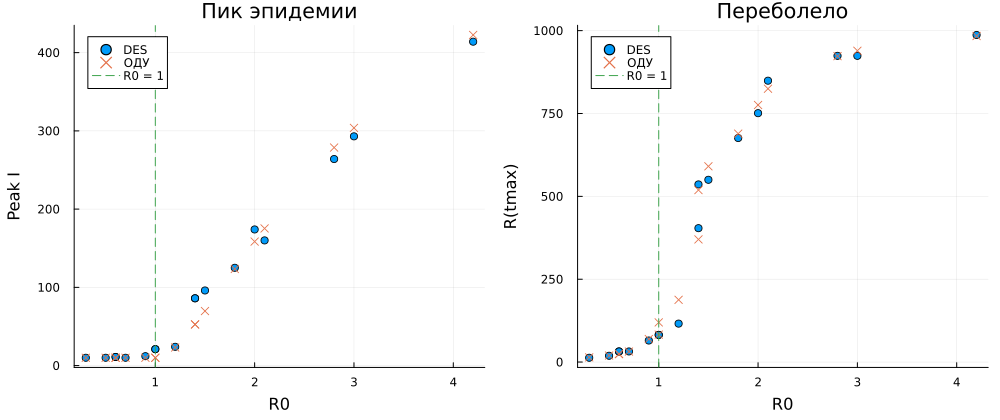

In [5]:
p1 = scatter(df_params.R0, df_params.peak_I, label = "DES", xlabel = "R0", ylabel = "Peak I", title = "Пик эпидемии", legend = :topleft)
scatter!(p1, df_params.R0, df_params.peak_I_ode, marker = :xcross, label = "ОДУ")
p2 = scatter(df_params.R0, df_params.final_R, label = "DES", xlabel = "R0", ylabel = "R(tmax)", title = "Переболело", legend = :topleft)
scatter!(p2, df_params.R0, df_params.final_R_ode, marker = :xcross, label = "ОДУ")
vline!(p1, [1.0], linestyle = :dash, label = "R0 = 1")
vline!(p2, [1.0], linestyle = :dash, label = "R0 = 1")
plt_params = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

## Сохранение графика

In [6]:
savefig(plt_params, plotsdir("sir_des_params.png"))
println("Результаты сохранены в data/sir_des_params.csv и plots/sir_des_params.png")

Результаты сохранены в data/sir_des_params.csv и plots/sir_des_params.png
